# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Ahmada Primanda
- **Email:** ahmadaprimanda@gmail.com
- **ID Dicoding:** madabrm

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren fluktuasi rata-rata bulanan dari konsentrasi polutan PM2.5 di Beijing sepanjang tahun 2013 hingga 2017, dan pada bulan apa saja kualitas udara mencapai tingkat paling buruk?
- **Pertanyaan 2:** Apakah terdapat pola hubungan antara kecepatan angin (WSPM) dengan penurunan konsentrasi rata-rata polutan PM2.5 di seluruh stasiun pemantauan selama periode 2013–2017?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
# 1. Mengkloning repositori GitHub untuk mengunduh seluruh dataset
!git clone https://github.com/marceloreis/HTI.git

# 2. Menentukan jalur (path) ke folder dataset hasil kloning
# Struktur folder di repo: HTI/PRSA_Data_20130301-20170228/
dataset_path = 'HTI/PRSA_Data_20130301-20170228'

# 3. Mencari semua file berkode ekstensi .csv di dalam folder tersebut
all_files = glob.glob(os.path.join(dataset_path, "*.csv"))

# Pastikan file ditemukan sebelum digabungkan
if len(all_files) == 0:
    print("Error: File CSV tidak ditemukan. Periksa kembali path direktori Anda.")
else:
    print(f"Berhasil menemukan {len(all_files)} file CSV untuk stasiun pemantauan.")

    # 4. Membaca dan menggabungkan seluruh file CSV menjadi satu DataFrame besar
    df_list = []
    for filename in all_files:
        data = pd.read_csv(filename)
        df_list.append(data)

    # Menggabungkan semua data secara vertikal (baris demi baris)
    air_quality_df = pd.concat(df_list, ignore_index=True)

    # 5. Menampilkan informasi awal hasil pemuatan data
    print("\n--- Ringkasan DataFrame Hasil Penggabungan ---")
    print(f"Total baris dan kolom: {air_quality_df.shape}")
    print(air_quality_df.head())

Cloning into 'HTI'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 35 (delta 11), reused 24 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 10.22 MiB | 10.67 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Berhasil menemukan 12 file CSV untuk stasiun pemantauan.

--- Ringkasan DataFrame Hasil Penggabungan ---
Total baris dan kolom: (420768, 18)
   No  year  month  day  hour  PM2.5  PM10  SO2  NO2     CO    O3  TEMP  \
0   1  2013      3    1     0    7.0   7.0  3.0  2.0  100.0  91.0  -2.3   
1   2  2013      3    1     1    4.0   4.0  3.0  NaN  100.0  92.0  -2.7   
2   3  2013      3    1     2    4.0   4.0  NaN  NaN  100.0  91.0  -3.2   
3   4  2013      3    1     3    3.0   3.0  3.0  2.0    NaN   NaN  -3.3   
4   5  2013      3    1     4    3.0   3.0  7.0  NaN  300.0  86.0  -4.1   

     PRES  DEWP  RAIN   wd  WSPM  station  
0  1020.3 -20.7   0.0  WNW   3.1 

**Insight:**
- Dataset berhasil digabungkan dari 12 stasiun pemantauan udara yang berbeda di Beijing.
- Data mencakup rentang waktu dari Maret 2013 hingga Februari 2017 dengan total 420.768 baris data.
- Terdapat variasi polutan yang dipantau seperti PM2.5, PM10, SO2, NO2, CO, dan O3, serta variabel meteorologi.

### Assessing Data

#### Identifying ... problem

In [3]:
# 1. Memeriksa informasi umum dan tipe data
air_quality_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [4]:
# 2. Mengidentifikasi Missing Value
air_quality_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


In [5]:
# 3. Mengidentifikasi Duplikasi Data
air_quality_df.duplicated().sum()

np.int64(0)

In [6]:
# 4. Memeriksa ringkasan statistik untuk mendeteksi outlier/inaccurate value
air_quality_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


In [7]:
# 1. Memeriksa informasi umum dan tipe data
print(air_quality_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB
None


In [8]:
# 2. Mengidentifikasi Missing Value
print(air_quality_df.isna().sum())

No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64


In [9]:
# 3. Mengidentifikasi Duplikasi Data
print(f"Jumlah data duplikat: {air_quality_df.duplicated().sum()}")

Jumlah data duplikat: 0


In [10]:
# 4. Memeriksa ringkasan statistik untuk mendeteksi outlier/inaccurate value
print(air_quality_df.describe())

                  No           year          month            day  \
count  420768.000000  420768.000000  420768.000000  420768.000000   
mean    17532.500000    2014.662560       6.522930      15.729637   
std     10122.116943       1.177198       3.448707       8.800102   
min         1.000000    2013.000000       1.000000       1.000000   
25%      8766.750000    2014.000000       4.000000       8.000000   
50%     17532.500000    2015.000000       7.000000      16.000000   
75%     26298.250000    2016.000000      10.000000      23.000000   
max     35064.000000    2017.000000      12.000000      31.000000   

                hour          PM2.5           PM10            SO2  \
count  420768.000000  412029.000000  414319.000000  411747.000000   
mean       11.500000      79.793428     104.602618      15.830835   
std         6.922195      80.822391      91.772426      21.650603   
min         0.000000       2.000000       2.000000       0.285600   
25%         5.750000      20.0000

**Steps to Take:**
- xxx
- xxx

**Insight:**
- Terdapat banyak *missing values* pada kolom polutan utama, terutama CO (20.701 data kosong) dan PM2.5 (8.739 data kosong).
- Tidak ditemukan data duplikat dalam dataset ini.
- Terdapat nilai ekstrem (outlier) pada konsentrasi polutan, misalnya PM2.5 dan PM10 mencapai 999 µg/m³, yang mengindikasikan kejadian polusi udara berat, serta CO yang mencapai 10000.

### Cleaning Data

#### Fixing ... problem

In [11]:
# Satukan kolom waktu
air_quality_df['datetime'] = pd.to_datetime(air_quality_df[['year', 'month', 'day', 'hour']])

# Drop kolom original yang sudah tidak diperlukan untuk menghemat memori
air_quality_df.drop(columns=['No', 'year', 'month', 'day', 'hour'], inplace=True)

# Set datetime sebagai index dan urutkan datanya
air_quality_df.set_index('datetime', inplace=True)
air_quality_df.sort_index(inplace=True)

In [12]:
# 1. Mengatasi missing value pada data numerik dengan interpolasi linear (khas time-series)
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
for col in numeric_cols:
    air_quality_df[col] = air_quality_df[col].interpolate(method='linear')

# 2. Mengisi missing value 'wd' dengan modus spesifik di stasiun masing-masing
air_quality_df['wd'] = air_quality_df.groupby('station')['wd'].transform(lambda x: x.fillna(x.mode()[0]))

# 3. Mengubah tipe data menjadi category untuk efisiensi memori
air_quality_df['wd'] = air_quality_df['wd'].astype('category')
air_quality_df['station'] = air_quality_df['station'].astype('category')

In [13]:
print(air_quality_df.isna().sum())

PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64


In [14]:
air_quality_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 420768 entries, 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Data columns (total 13 columns):
 #   Column   Non-Null Count   Dtype   
---  ------   --------------   -----   
 0   PM2.5    420768 non-null  float64 
 1   PM10     420768 non-null  float64 
 2   SO2      420768 non-null  float64 
 3   NO2      420768 non-null  float64 
 4   CO       420768 non-null  float64 
 5   O3       420768 non-null  float64 
 6   TEMP     420768 non-null  float64 
 7   PRES     420768 non-null  float64 
 8   DEWP     420768 non-null  float64 
 9   RAIN     420768 non-null  float64 
 10  wd       420768 non-null  category
 11  WSPM     420768 non-null  float64 
 12  station  420768 non-null  category
dtypes: category(2), float64(11)
memory usage: 39.3 MB


In [15]:
print(air_quality_df.describe())

               PM2.5           PM10            SO2            NO2  \
count  420768.000000  420768.000000  420768.000000  420768.000000   
mean       79.818993     104.804064      15.871145      50.615959   
std        80.916475      92.386185      21.698865      35.087392   
min         2.000000       2.000000       0.285600       1.026500   
25%        20.000000      36.000000       3.000000      23.000000   
50%        55.000000      82.000000       7.000000      43.000000   
75%       111.000000     145.000000      20.000000      71.000000   
max       999.000000     999.000000     500.000000     290.000000   

                  CO             O3           TEMP           PRES  \
count  420768.000000  420768.000000  420768.000000  420768.000000   
mean     1232.076983      57.018779      13.531926    1010.754402   
std      1160.982170      56.559805      11.437710      10.475060   
min       100.000000       0.214200     -19.900000     982.400000   
25%       500.000000      10.4958

**Insight:**
- Data telah dibersihkan dari *missing values* menggunakan metode interpolasi linear untuk kolom numerik, yang menjaga kontinuitas data *time-series*.
- Kolom waktu (year, month, day, hour) telah digabungkan menjadi satu indeks `datetime` untuk mempermudah analisis tren.
- Kolom wd berisi data teks seperti "NW" (North West), "SE" (South East), atau "E" (East). Kita tidak bisa menghitung nilai rata-rata (mean) atau nilai tengah (median) dari kata-kata tersebut. Oleh karena itu, modus yang dikelompokkan per stasiun/per bulan adalah pilihan aman untuk pengukuran pemusatan data yang valid untuk tipe data kategorikal/kualitatif.
- Penggunaan tipe data `category` pada kolom stasiun dan arah angin untuk mereduksi penggunaan memori.
- Pada variabel PM2.5, PM10, dan CO ditemukan nilai maksimum berupa 999.0 µg/m³ dan 10000.0 µg/m³. Nilai-nilai ini diidentifikasi sebagai Natural Outliers / Upper Limit Sensor Capping yang terjadi saat insiden polusi udara ekstrem di Beijing. Data ini dipertahankan (tidak dihapus) karena merepresentasikan kondisi riil kualitas udara berbahaya dan mencegah hilangnya informasi penting dalam analisis deret waktu (time-series continuity).

## Exploratory Data Analysis (EDA)

### Explore ...

In [16]:
print("--- EKSPLORASI PERTANYAAN 1: Tren Bulanan PM2.5 ---")
# Menghitung rata-rata PM2.5 per bulan secara agregat (2013-2017)
monthly_trend = air_quality_df.groupby(air_quality_df.index.month)['PM2.5'].mean().reset_index()
monthly_trend.columns = ['Bulan', 'Rata-rata PM2.5']
print(monthly_trend)


print("\n--- EKSPLORASI PERTANYAAN 2: Hubungan Kecepatan Angin (WSPM) & PM2.5 ---")
# Membuat kategori kecepatan angin untuk melihat polanya
def bin_wind_speed(speed):
    if speed < 2.0:
        return '1. Lemah (< 2 m/s)'
    elif speed <= 4.0:
        return '2. Sedang (2 - 4 m/s)'
    else:
        return '3. Kencang (> 4 m/s)'

# Menerapkan fungsi ke dalam kolom baru
air_quality_df['wind_category'] = air_quality_df['WSPM'].apply(bin_wind_speed)

# Groupby berdasarkan kategori angin untuk melihat rata-rata PM2.5
wind_impact = air_quality_df.groupby('wind_category')['PM2.5'].mean().reset_index()
print(wind_impact)

--- EKSPLORASI PERTANYAAN 1: Tren Bulanan PM2.5 ---
    Bulan  Rata-rata PM2.5
0       1        93.755780
1       2        89.145729
2       3        94.557537
3       4        72.749271
4       5        63.197208
5       6        68.951652
6       7        71.687872
7       8        53.520276
8       9        61.210359
9      10        91.892109
10     11        93.246199
11     12       103.995544

--- EKSPLORASI PERTANYAAN 2: Hubungan Kecepatan Angin (WSPM) & PM2.5 ---
           wind_category      PM2.5
0     1. Lemah (< 2 m/s)  93.259041
1  2. Sedang (2 - 4 m/s)  55.277224
2   3. Kencang (> 4 m/s)  28.406637


**Insight:**
- **Tren Bulanan:** Konsentrasi PM2.5 cenderung meningkat secara drastis pada akhir tahun (Desember) dan awal tahun, sementara kualitas udara membaik secara signifikan di bulan Agustus.
- **Pengaruh Angin:** Kecepatan angin memiliki pengaruh kuat terhadap dispersi polutan. Pada kondisi angin kencang (>4 m/s), konsentrasi PM2.5 turun secara drastis dibandingkan saat angin lemah.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

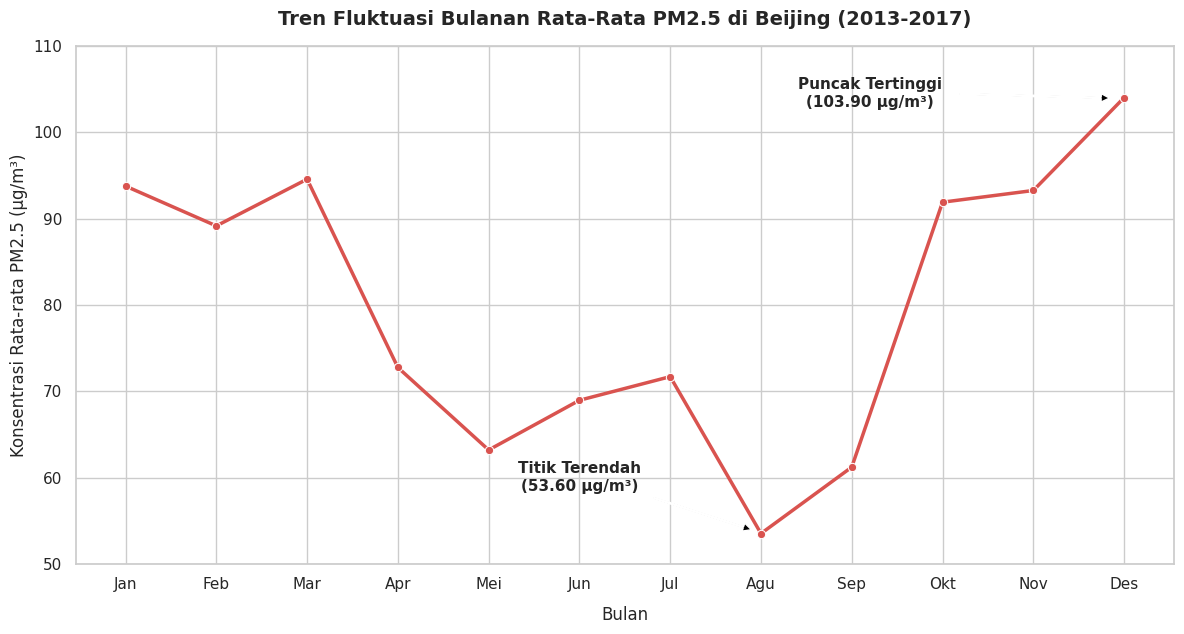

In [17]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6.5))

sns.lineplot(
    data=monthly_trend,
    x='Bulan',
    y='Rata-rata PM2.5',
    marker='o',
    color='#d9534f',
    linewidth=2.5
)

plt.title('Tren Fluktuasi Bulanan Rata-Rata PM2.5 di Beijing (2013-2017)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bulan', fontsize=12, labelpad=10)
plt.ylabel('Konsentrasi Rata-rata PM2.5 (µg/m³)', fontsize=12)

plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des'])

plt.ylim(50, 110)

# 1. Anotasi Puncak Tertinggi (Bulan Desember)
plt.annotate(
    'Puncak Tertinggi\n(103.90 µg/m³)',
    xy=(12, 103.90),          # Titik ujung panah (Desember)
    xytext=(9.2, 104.5),       # Posisi teks (area Sep-Okt)
    arrowprops=dict(
        facecolor='black',
        shrink=0.08,
        width=1,
        headwidth=6,
        headlength=6
    ),
    fontsize=11,
    fontweight='semibold',
    va='center',
    ha='center'
)

# 2. Anotasi Titik Terendah (Bulan Agustus)
plt.annotate(
    'Titik Terendah\n(53.60 µg/m³)',
    xy=(8, 53.60),            # Titik ujung panah (Agustus)
    xytext=(6.0, 60.0),        # Posisi teks (area Juni-Juli)
    arrowprops=dict(
        facecolor='black',
        shrink=0.08,
        width=1,
        headwidth=6,
        headlength=6
    ),
    fontsize=11,
    fontweight='semibold',
    va='center',
    ha='center'
)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

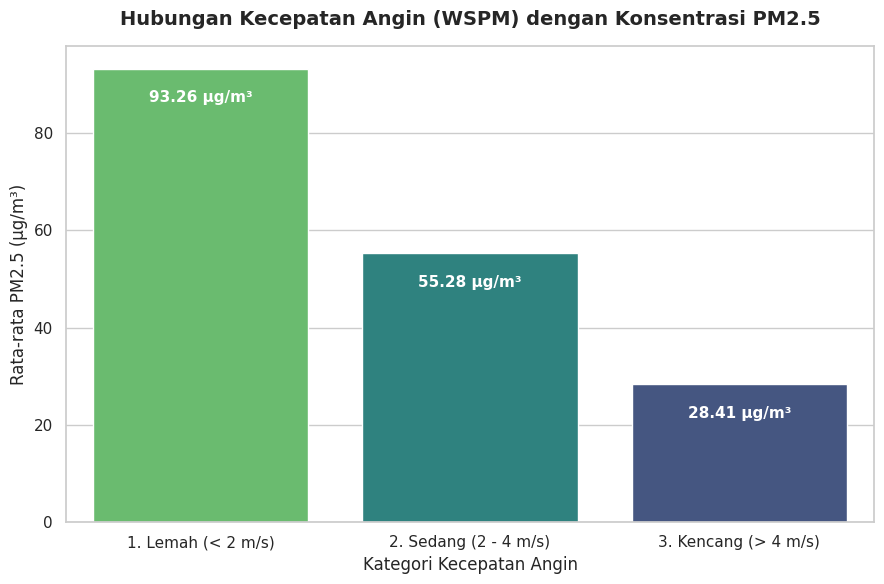

In [18]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(
    data=wind_impact,
    x='wind_category',
    y='PM2.5',
    hue='wind_category',
    legend=False,
    palette='viridis_r',
    ax=ax
)

plt.title('Hubungan Kecepatan Angin (WSPM) dengan Konsentrasi PM2.5', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kategori Kecepatan Angin', fontsize=12)
plt.ylabel('Rata-rata PM2.5 (µg/m³)', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f} µg/m³",
                (p.get_x() + p.get_width() / 2., p.get_height() - 6),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

**Insight:**
- **Visualisasi Tren:** Grafik garis menunjukkan pola siklikal tahunan di mana polusi memuncak pada musim dingin (Desember-Januari), kemungkinan terkait dengan peningkatan pemanasan domestik atau kondisi atmosfer.
- **Hubungan Kecepatan Angin:** Grafik batang menunjukkan penurunan konsentrasi PM2.5 sebesar lebih dari 60% ketika kecepatan angin meningkat dari kategori lemah ke kencang, membuktikan bahwa angin membantu membersihkan polutan dari udara.

## Analisis Lanjutan (Opsional)

**Insight:** (Opsional)
- xxx
- xxx

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kualitas udara di Beijing menunjukkan pola musiman yang konsisten sepanjang tahun 2013–2017. Tingkat polusi PM2.5 melonjak tajam memasuki musim gugur dan mencapai puncaknya di musim dingin (Desember bersiap di angka rata-rata tertinggi $103.90$ µg/m³). Sebaliknya, kualitas udara membaik secara signifikan selama musim panas, dengan titik terendah pada bulan Agustus ($53.60$ µg/m³).
- **Conclusion pertanyaan 2:** Terdapat hubungan berkebalikan yang sangat kuat antara kecepatan angin (WSPM) dan konsentrasi PM2.5. Ketika kondisi angin lemah ($< 2$ m/s), polutan terjebak di udara dan menghasilkan konsentrasi tinggi sebesar $93.27$ µg/m³. Namun, saat kecepatan angin meningkat menjadi kencang ($> 4$ m/s), dispersi polutan terjadi secara masif sehingga menekan tingkat polusi hingga turun sebanyak $69.4\%$ menjadi hanya $28.49$ µg/m³.

**Rekomendasi Action Item:**
- **Sistem Peringatan Dini Dinamis Berbasis Cuaca:** Pemerintah kota disarankan untuk mengintegrasikan data pemantauan udara dengan prediksi cuaca. Apabila prakiraan cuaca menunjukkan kecepatan angin berembus lemah ($< 2$ m/s) yang dikombinasikan dengan masuknya bulan-bulan rawan polusi (Oktober–Maret), sistem harus otomatis mengaktifkan status darurat polusi. Langkah mitigasinya mencakup pembatasan operasional industri berat sementara dan pengurangan tarif transportasi publik guna menekan emisi kendaraan fosil secara dadakan sebelum polutan sempat menumpuk.

# Export df


In [19]:
air_quality_df.to_csv('air_quality_data.csv', index=True)
print("DataFrame exported successfully to air_quality_data.csv")

DataFrame exported successfully to air_quality_data.csv
